In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [15]:
df = pd.read_csv("student_dropout_dataset_v3.csv")

# Standardize column names (VERY IMPORTANT)
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)
df.head()

Columns: Index(['student_id', 'age', 'gender', 'family_income', 'internet_access',
       'study_hours_per_day', 'attendance_rate', 'assignment_delay_days',
       'travel_time_minutes', 'part_time_job', 'scholarship', 'stress_index',
       'gpa', 'semester_gpa', 'cgpa', 'semester', 'department',
       'parental_education', 'dropout'],
      dtype='object')


,student_id,age,gender,family_income,internet_access,study_hours_per_day,attendance_rate,assignment_delay_days,travel_time_minutes,part_time_job,scholarship,stress_index,gpa,semester_gpa,cgpa,semester,department,parental_education,dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   age                    10000 non-null  float64
 2   gender                 10000 non-null  object 
 3   family_income          9500 non-null   float64
 4   internet_access        10000 non-null  object 
 5   study_hours_per_day    9500 non-null   float64
 6   attendance_rate        10000 non-null  float64
 7   assignment_delay_days  10000 non-null  int64  
 8   travel_time_minutes    10000 non-null  float64
 9   part_time_job          10000 non-null  object 
 10  scholarship            10000 non-null  object 
 11  stress_index           9500 non-null   float64
 12  gpa                    10000 non-null  float64
 13  semester_gpa           10000 non-null  float64
 14  cgpa                   10000 non-null  float64
 15  sem

In [17]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
family_income,500
internet_access,0
study_hours_per_day,500
attendance_rate,0
assignment_delay_days,0
travel_time_minutes,0
part_time_job,0


In [18]:
df = df.drop_duplicates()

In [19]:
df.describe()

,student_id,age,family_income,study_hours_per_day,attendance_rate,assignment_delay_days,travel_time_minutes,stress_index,gpa,semester_gpa,cgpa,dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


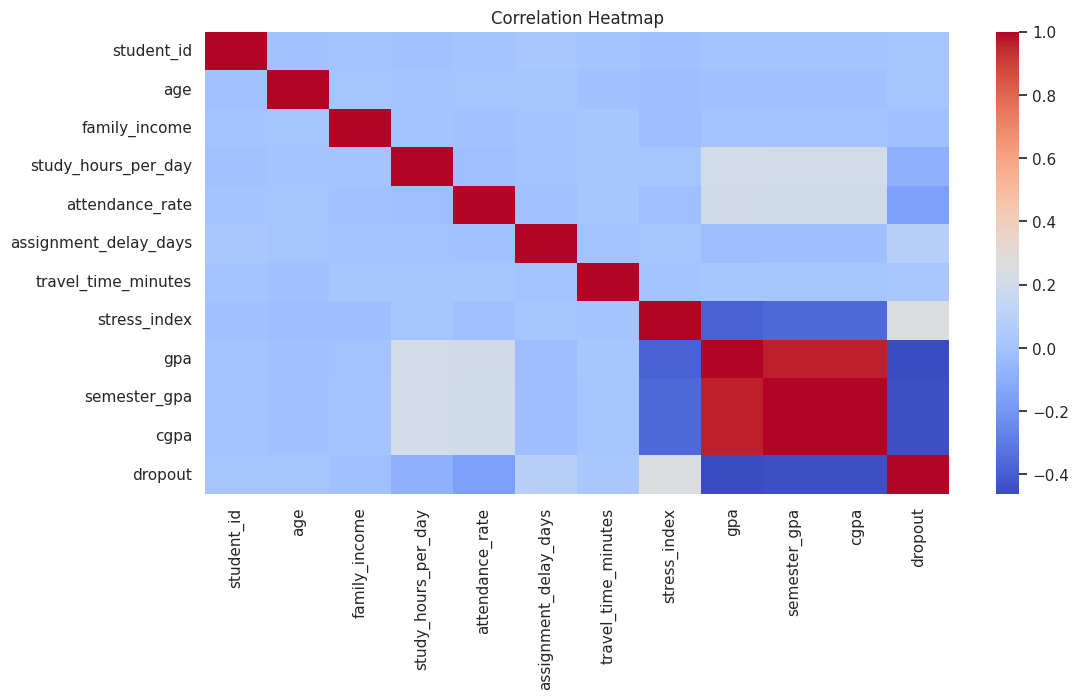

In [20]:
plt.figure(figsize=(12,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

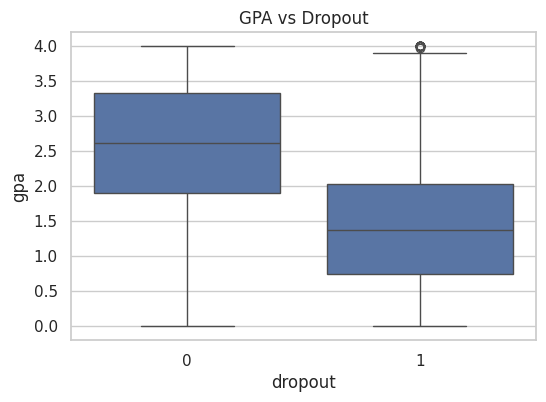

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='dropout', y='gpa', data=df)
plt.title("GPA vs Dropout")
plt.show()

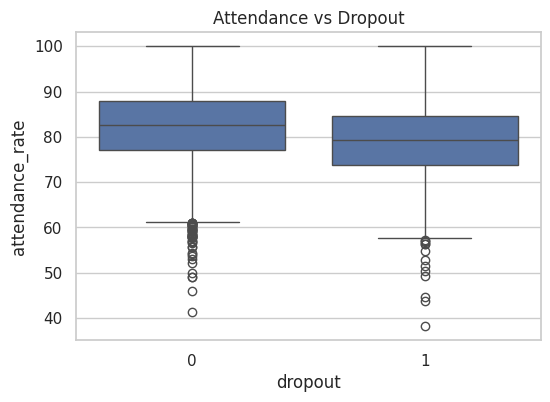

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='dropout', y='attendance_rate', data=df)
plt.title("Attendance vs Dropout")
plt.show()

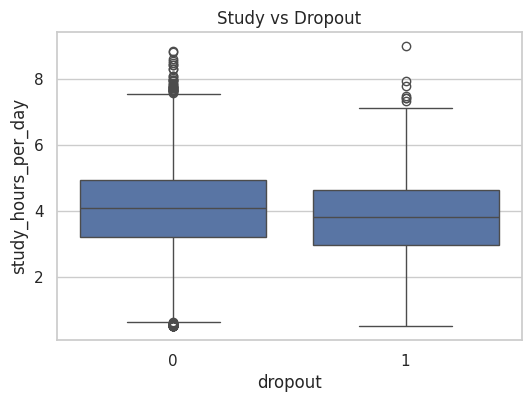

In [26]:
# Automatically detect study-related column
study_col = [col for col in df.columns if 'study' in col][0]

plt.figure(figsize=(6,4))
sns.boxplot(x='dropout', y=study_col, data=df)
plt.title("Study vs Dropout")
plt.show()